# ChemiAI — предсказание противовирусной активности соединений

Ноутбук с решением задачи регрессии по молекулярным дескрипторам: для каждого соединения предсказываются **IC50**, **CC50** и **SI**.

## Описание задачи

Разработка лекарств — длительный процесс синтеза и биологического тестирования. Машинное обучение позволяет оценивать перспективность соединений **до** лабораторных экспериментов.

В датасете — свойства молекул и их активность против вируса гриппа. Нужно построить модель, предсказывающую для новых соединений:

| Таргет | Смысл |
|--------|--------|
| **IC50 (mM)** | концентрация, при которой подавляется 50% активности вируса |
| **CC50 (mM)** | концентрация токсичности для 50% клеток |
| **SI** | индекс селективности (Selectivity Index) |

**Метрика:** среднее RMSE по трём таргетам:

$$\text{score} = \frac{RMSE(IC50) + RMSE(CC50) + RMSE(SI)}{3}$$

**Формат сабмита:** `index, IC50, CC50, SI` (см. `sample_submission.csv`).

Подробнее — в [DESCRIPTION.md](./DESCRIPTION.md). Данные: [Google Drive](https://drive.google.com/drive/folders/1m1PS44rF9HqIAOUZQeopU5sqwgi6YfO8?usp=sharing).

## План работы

1. **Загрузка данных** — скачивание с Google Drive и чтение `train` / `test` / `sample_submission`.
2. **EDA** — распределения таргетов и признаков, пропуски, корреляции.
3. **Предобработка** — масштабирование, отбор признаков при необходимости.
4. **Моделирование** — baseline и улучшенные модели (multi-target или отдельные регрессоры).
5. **Валидация** — кросс-валидация по метрике соревнования.
6. **Сабмит** — предсказания на `test.csv` и сохранение `submission.csv`.

## 1. Настройка окружения

## 1.1 Установка библиотек

In [117]:
import gdown
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer


## 1.2 Глобальные переменные

In [118]:
# Воспроизводимость
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Пути
ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data"
GDRIVE_FOLDER_ID = "1m1PS44rF9HqIAOUZQeopU5sqwgi6YfO8"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

## 2. Загрузка данных

Датасет: [Google Drive](https://drive.google.com/drive/folders/1m1PS44rF9HqIAOUZQeopU5sqwgi6YfO8?usp=sharing) (`train.csv`, `test.csv`, `sample_submission.csv`).

In [119]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
gdown.download_folder(id=GDRIVE_FOLDER_ID, output=str(DATA_DIR))

Retrieving folder contents


Processing file 1LL6moSzpUVxJUTMeXihWvUxBJNjvj6EH sample_submission.csv
Processing file 1Ui2t87X3in-Wu-pnjkDXa_VtPsVafi0l test.csv
Processing file 159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl train.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1LL6moSzpUVxJUTMeXihWvUxBJNjvj6EH
To: /Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/mephi-unsupervised-learning/ChemiAI/data/sample_submission.csv
100%|██████████| 15.4k/15.4k [00:00<00:00, 331kB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ui2t87X3in-Wu-pnjkDXa_VtPsVafi0l
To: /Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/mephi-unsupervised-learning/ChemiAI/data/test.csv
100%|██████████| 441k/441k [00:00<00:00, 898kB/s]
Downloading...
From: https://drive.google.com/uc?id=159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl
To: /Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/mephi-unsupervised-learning/ChemiAI/data/train.csv
100%|██████████| 1.36M/1.36M [00:00<00:00, 1.96MB/s]
Download completed


['/Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/mephi-unsupervised-learning/ChemiAI/data/sample_submission.csv',
 '/Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/mephi-unsupervised-learning/ChemiAI/data/test.csv',
 '/Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/mephi-unsupervised-learning/ChemiAI/data/train.csv']

In [120]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"Sample submission: {sample_submission.shape}")
train.head()

Train: (751, 214)
Test:  (250, 211)
Sample submission: (250, 4)


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [121]:
print("\nTrain первые 8 колонок:", train.columns[:8].tolist())
print("Test  первые 8 колонок:", test.columns[:8].tolist())
print("Sample колонки:", sample_submission.columns.tolist())


Train первые 8 колонок: ['index', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex']
Test  первые 8 колонок: ['index', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt']
Sample колонки: ['index', 'IC50', 'CC50', 'SI']


## 2.1 Проверка расхождения колонок `train` / `test`

In [122]:
# Колонки, которые есть в train, но нет в test
only_in_train = sorted(set(train.columns) - set(test.columns))

# Колонки, которые есть в test, но нет в train
only_in_test = sorted(set(test.columns) - set(train.columns))

print("Только в train:", only_in_train)
print("Только в test:", only_in_test)

Только в train: ['CC50, mM', 'IC50, mM', 'SI']
Только в test: []


In [123]:
TARGET_COLS = ["IC50, mM", "CC50, mM", "SI"]
ID_COL = "index"

FEATURE_COLS = [c for c in train.columns if c not in [ID_COL, *TARGET_COLS]]

X_train = train[FEATURE_COLS].copy()
y_train = train[TARGET_COLS].copy()
X_test = test[FEATURE_COLS].copy()

print(X_train.shape, y_train.shape, X_test.shape)

(751, 210) (751, 3) (250, 210)


## 2.2 Обработка пропусков

Визуализация пропусков:

<Figure size 3600x1200 with 0 Axes>

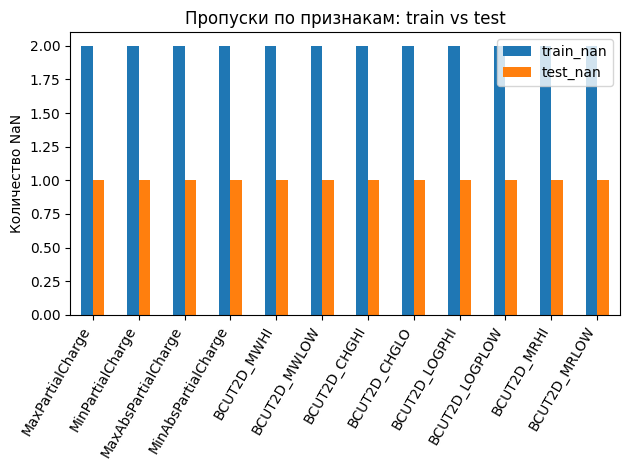

In [127]:
nan_train = X_train.isna().sum()
nan_test = X_test.isna().sum()

nan_cmp = pd.DataFrame({
    "train_nan": nan_train,
    "test_nan": nan_test
})

nan_cmp = nan_cmp[(nan_cmp["train_nan"] > 0) | (nan_cmp["test_nan"] > 0)]
plt.figure(figsize=(12, 4), dpi=300)
ax = nan_cmp.sort_values("train_nan", ascending=False).plot(kind="bar")
ax.set_title("Пропуски по признакам: train vs test")
ax.set_ylabel("Количество NaN")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

Посчитаем общее количество пропусков (`NaN`) в каждом датафрейме:
- `X_train.isna()` -> таблица `True/False`, где `True` = ячейка с `NaN`
- `.sum()` (первый) -> сколько `NaN` в каждом столбце
- `.sum()` (второй) -> сумма по всем столбцам, то есть общее число `NaN` в таблице

In [ ]:
print("NaN в X_train:", X_train.isna().sum().sum())
print("NaN в y_train:", y_train.isna().sum().sum())
print("NaN в X_test :", X_test.isna().sum().sum())

NaN в X_train: 24
NaN в y_train: 0
NaN в X_test : 12


In [ ]:
nan_by_col = X_train.isna().sum()

print(nan_by_col[nan_by_col > 0].sort_values(ascending=False).head(20))

MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64


In [ ]:
nan_by_col = X_test.isna().sum()

print(nan_by_col[nan_by_col > 0].sort_values(ascending=False).head(20))

MaxPartialCharge       1
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
BCUT2D_MWHI            1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
dtype: int64


Используем `SimpleImputer`, чтобы убрать немногочисленные пропуски в признаках без потери строк.

Стратегия `median` выбрана, потому что она устойчива к выбросам и хорошо подходит для числовых химических дескрипторов.

`fit` делаем только на `X_train`, чтобы не допустить утечки информации из теста.
К `X_test` применяем только `transform` с уже выученными значениями.

После преобразования возвращаем `DataFrame` с исходными `columns` и `index`, чтобы сохранить имена признаков и корректное выравнивание данных для обучения и предсказания.

In [ ]:
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("NaN train:", X_train_imp.isna().sum().sum())
print("NaN test :", X_test_imp.isna().sum().sum())

NaN train: 0
NaN test : 0


## 2.3 Визуализация таргетов

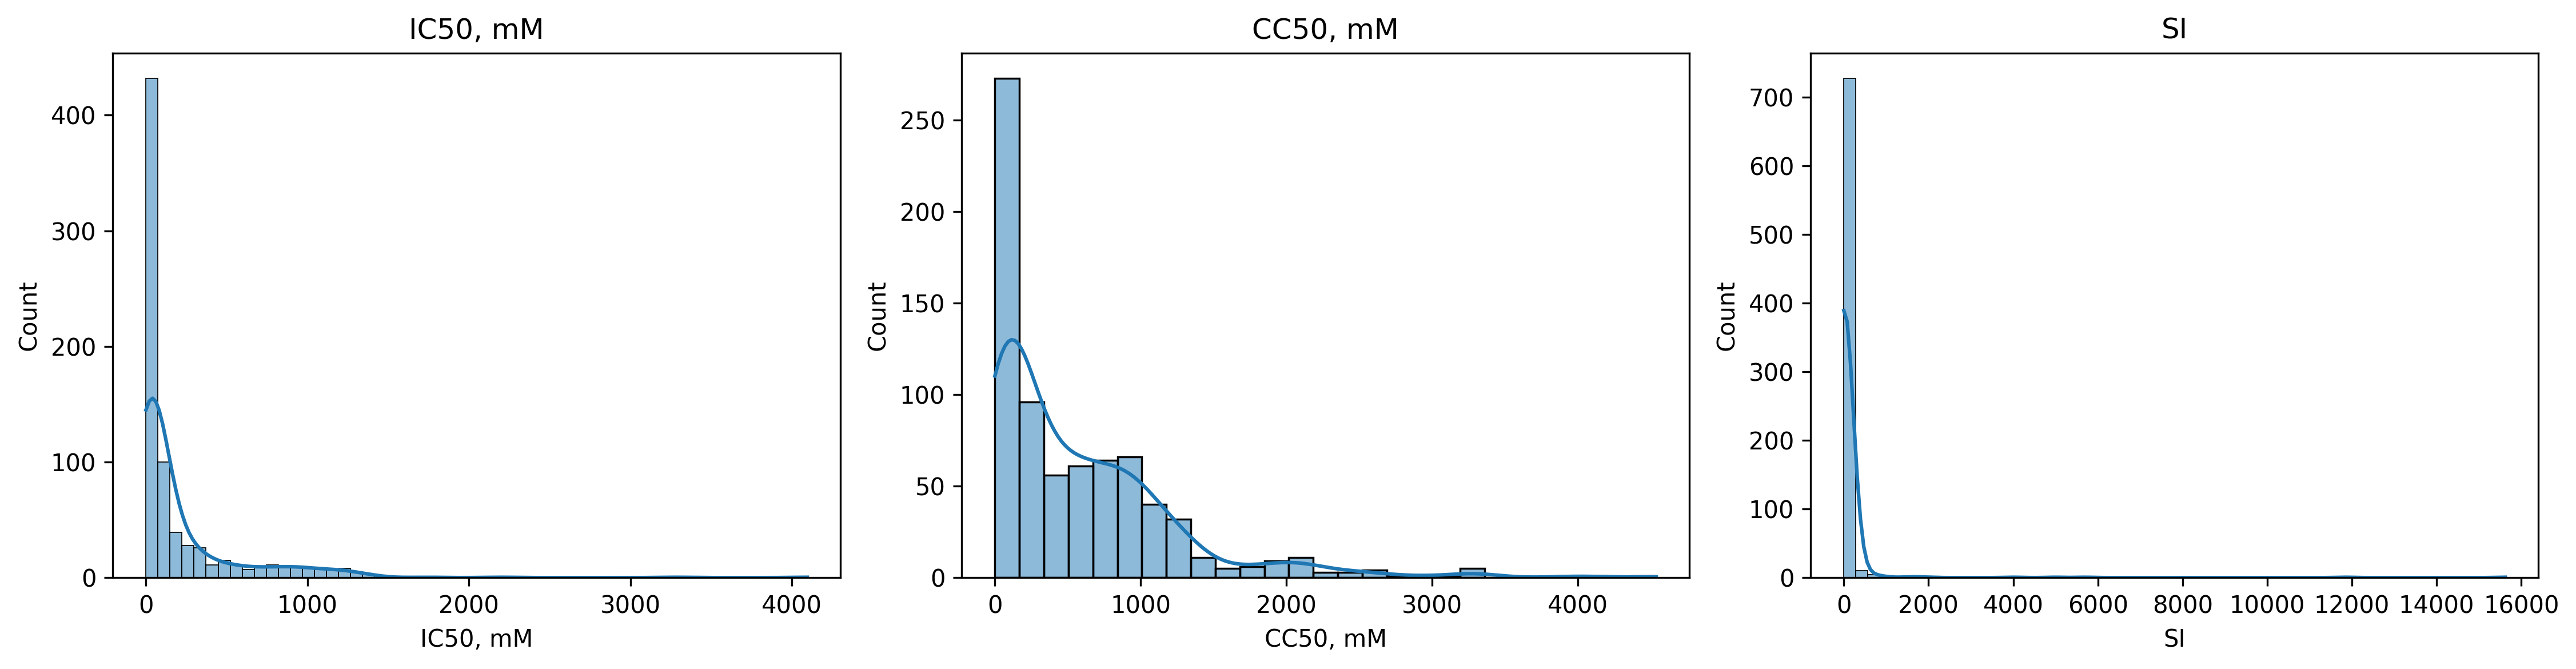

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=300)

for ax, col in zip(axes, ["IC50, mM", "CC50, mM", "SI"]):
    sns.histplot(train[col], kde=True, ax=ax)
    ax.set_title(col)
    
plt.tight_layout()
plt.show()